# GPU Experiments: Optimizer and Anisotropy Study

> **Note:** This notebook assumes a GPU is available (CUDA/ROCm). The user may choose not to run it. All heavy cells are designed to be executed manually and use small epoch counts by default.

## Setup (GPU)

In [1]:
import os
from pathlib import Path
import math
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
MODEL_NAME = 'distilbert-base-uncased'

from IPython.display import display


Device: cuda


In [ ]:
class FastTensorDataLoader:
    def __init__(self, *tensors, batch_size=32, shuffle=False):
        assert len(tensors) > 0, 
        assert all(t.shape[0] == tensors[0].shape[0] for t in tensors)
        self.tensors = list(tensors)
        self.dataset_len = self.tensors[0].shape[0]
        self.batch_size = batch_size
        self.shuffle = shuffle
        n_batches, remainder = divmod(self.dataset_len, self.batch_size)
        if remainder > 0:
            n_batches += 1
        self.n_batches = n_batches

    def __iter__(self):
        if self.shuffle:
            r = torch.randperm(self.dataset_len)
            self.tensors = [t[r] for t in self.tensors]
        self.i = 0
        return self

    def __next__(self):
        if self.i >= self.dataset_len:
            raise StopIteration
        batch = tuple(t[self.i:self.i + self.batch_size] for t in self.tensors)
        self.i += self.batch_size
        return batch

    def __len__(self):
        return self.n_batches


### Load dataset and tokenizer

In [ ]:
dataset = load_dataset('glue', 'sst2')
length_train = 20_000
small_train = dataset['train'].shuffle(seed=0).select(range(20000))
val_split = dataset['validation']

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch, max_length=128):
    return tokenizer(batch['sentence'], padding='max_length', truncation=True, max_length=max_length)

encoded_train = small_train.map(tokenize_function, batched=True)
encoded_val = val_split.map(tokenize_function, batched=True)
cols = ['input_ids', 'attention_mask', 'label']
encoded_train.set_format(type='torch', columns=cols)
encoded_val.set_format(type='torch', columns=cols)

def column_to_tensor(ds, key, dtype=None):
    data = ds[key]
    arr = np.array(data)
    tensor = torch.from_numpy(arr)
    if dtype is not None:
        tensor = tensor.to(dtype)
    return tensor.contiguous()

train_tensors = (
    column_to_tensor(encoded_train, 'input_ids', dtype=torch.long),
    column_to_tensor(encoded_train, 'attention_mask', dtype=torch.long),
    column_to_tensor(encoded_train, 'label', dtype=torch.long),
)

val_tensors = (
    column_to_tensor(encoded_val, 'input_ids', dtype=torch.long),
    column_to_tensor(encoded_val, 'attention_mask', dtype=torch.long),
    column_to_tensor(encoded_val, 'label', dtype=torch.long),
)

train_loader = FastTensorDataLoader(*train_tensors, batch_size=32, shuffle=True)
val_loader   = FastTensorDataLoader(*val_tensors,   batch_size=64, shuffle=False)

def split_batch(batch):
    if isinstance(batch, dict):
        inputs = {
            'input_ids': batch['input_ids'],
            'attention_mask': batch['attention_mask'],
        }
        labels = batch.get('labels', batch.get('label'))
    else:
        input_ids, attention_mask, labels = batch
        inputs = {'input_ids': input_ids, 'attention_mask': attention_mask}
    return inputs, labels


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

## Fine-tuning with Adam vs SGD

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

def train_loop(optimizer_name='adam', num_epochs=2, lr=5e-5, weight_decay=0.01):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
    use_parallel = (device.type == 'cuda') and (torch.cuda.device_count() > 1)
    if use_parallel:
        print(f"Wrapping model with DataParallel on {torch.cuda.device_count()} GPUs")
        model = torch.nn.DataParallel(model)

    model.to(device)

    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    loss_history = []
    model.train()

    for epoch in range(num_epochs):
        for batch in train_loader:
            inputs, labels = split_batch(batch)

            inputs = {k: v.to(device) for k, v in inputs.items()}
            if labels is None:
                raise ValueError("Labels are required for training but were not provided.")
            labels = labels.to(device)
            inputs["labels"] = labels
            outputs = model(**inputs)
            loss = outputs.loss
            if loss.dim() > 0:
                loss = loss.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())

        print(f"[{optimizer_name}] epoch {epoch+1}/{num_epochs}: loss={loss_history[-1]:.4f}")

    state_dict = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
    ckpt_path = RESULTS_DIR / f"model_{optimizer_name}.pt"
    torch.save(state_dict, ckpt_path)

    return ckpt_path

adam_ckpt = RESULTS_DIR / "model_adam.pt"
sgd_ckpt = RESULTS_DIR / "model_sgd.pt"
print("Planned checkpoints:", adam_ckpt, sgd_ckpt)


adam_ckpt = train_loop("adam", num_epochs=10, lr=5e-5)
sgd_ckpt  = train_loop("sgd",  num_epochs=15, lr=1e-3, weight_decay=0.0)


Planned checkpoints: results/model_adam.pt results/model_sgd.pt


2025-12-05 02:06:04.380561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764900364.585783      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764900364.652939      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Wrapping model with DataParallel on 2 GPUs


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


[adam] epoch 1/10: loss=0.2389
[adam] epoch 2/10: loss=0.1758
[adam] epoch 3/10: loss=0.1875
[adam] epoch 4/10: loss=0.0011
[adam] epoch 5/10: loss=0.0043
[adam] epoch 6/10: loss=0.0003
[adam] epoch 7/10: loss=0.1401
[adam] epoch 8/10: loss=0.0113
[adam] epoch 9/10: loss=0.0159
[adam] epoch 10/10: loss=0.0275


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wrapping model with DataParallel on 2 GPUs
[sgd] epoch 1/15: loss=0.0761
[sgd] epoch 2/15: loss=0.1994
[sgd] epoch 3/15: loss=0.1963
[sgd] epoch 4/15: loss=0.1617
[sgd] epoch 5/15: loss=0.1069
[sgd] epoch 6/15: loss=0.0077
[sgd] epoch 7/15: loss=0.2330
[sgd] epoch 8/15: loss=0.1050
[sgd] epoch 9/15: loss=0.0334
[sgd] epoch 10/15: loss=0.0181
[sgd] epoch 11/15: loss=0.0211
[sgd] epoch 12/15: loss=0.0069
[sgd] epoch 13/15: loss=0.0484
[sgd] epoch 14/15: loss=0.0015
[sgd] epoch 15/15: loss=0.0100


## Extract CLS embeddings for Adam and SGD

In [5]:
@torch.no_grad()
def collect_embeddings(model_path, split_loader, normalize=False):
    model = AutoModel.from_pretrained(MODEL_NAME)
    if model_path.exists():
        full_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
        full_model.load_state_dict(torch.load(model_path, map_location=device))
        model.load_state_dict(full_model.distilbert.state_dict())
    model.to(device)
    model.eval()
    embeddings, labels = [], []
    for batch in split_loader:
        inputs, label_tensor = split_batch(batch)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        cls = outputs.last_hidden_state[:, 0, :]
        if normalize:
            cls = torch.nn.functional.normalize(cls, p=2, dim=-1)
        embeddings.append(cls.cpu())
        if label_tensor is not None:
            lbl = label_tensor if isinstance(label_tensor, torch.Tensor) else torch.tensor(label_tensor)
            labels.append(lbl.cpu())
    embeddings = torch.cat(embeddings, dim=0)
    labels = torch.cat(labels, dim=0) if labels else None
    return embeddings, labels

adam_embeddings, y_val = collect_embeddings(adam_ckpt, val_loader)
sgd_embeddings, _ = collect_embeddings(sgd_ckpt, val_loader)

torch.save({'embeddings': adam_embeddings, 'labels': y_val}, RESULTS_DIR / 'cls_adam.pt')
torch.save({'embeddings': sgd_embeddings, 'labels': y_val}, RESULTS_DIR / 'cls_sgd.pt')
print('Saved CLS embeddings for both optimizers.')


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Saved CLS embeddings for both optimizers.


## Covariance and effective dimension for Adam vs SGD

Covariance summary (values depend on the particular fine-tuning run):


,optimizer,lambda_max,trace,d_eff
0,Adam,153.583984,180.799606,1.177204
1,SGD,88.354851,161.022293,1.822450


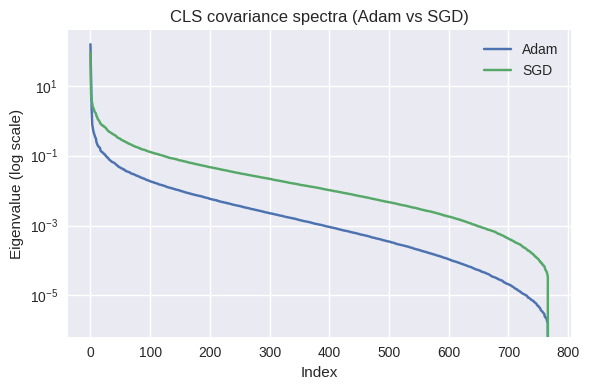

In [6]:
def covariance_and_rank(tensor):
    arr = tensor.numpy()
    arr = arr - arr.mean(axis=0, keepdims=True)
    cov = arr.T @ arr / arr.shape[0]
    evals = np.linalg.eigvalsh(cov)
    evals = np.sort(evals)[::-1]
    lam_max = evals[0]
    trace_val = evals.sum()
    eff_dim = trace_val / lam_max
    return cov, evals, lam_max, trace_val, eff_dim

cov_adam, evals_adam, lam_adam, trace_adam, deff_adam = covariance_and_rank(adam_embeddings)
cov_sgd, evals_sgd, lam_sgd, trace_sgd, deff_sgd = covariance_and_rank(sgd_embeddings)

summary_df = pd.DataFrame([
    {'optimizer': 'Adam', 'lambda_max': lam_adam, 'trace': trace_adam, 'd_eff': deff_adam},
    {'optimizer': 'SGD', 'lambda_max': lam_sgd, 'trace': trace_sgd, 'd_eff': deff_sgd},
])
print('Covariance summary (values depend on the particular fine-tuning run):')
display(summary_df)

fig, ax = plt.subplots(figsize=(6,4))
ax.semilogy(evals_adam, label='Adam')
ax.semilogy(evals_sgd, label='SGD')
ax.set_title('CLS covariance spectra (Adam vs SGD)')
ax.set_xlabel('Index')
ax.set_ylabel('Eigenvalue (log scale)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gpu_covariance_spectra.png', dpi=300, bbox_inches='tight')
plt.show()


## Projection + whitening experiments

## PCA vs Gaussian projections on GPU
This optional cell mirrors the CPU analysis: it compares PCA compression (via empirical eigenvectors) to Gaussian projections for the GPU-derived embeddings.

In [ ]:
def train_logreg(X, y, C=1.0, max_iter=200):
    clf = LogisticRegression(
        C=C,
        max_iter=max_iter,
        multi_class="multinomial",
        solver="lbfgs",
    )
    clf.fit(X, y)

    probs = clf.predict_proba(X)
    preds = probs.argmax(axis=1)
    acc = accuracy_score(y, preds)
    nll = log_loss(y, probs, labels=np.unique(y))

    return clf, acc, nll

if 'adam_embeddings' in globals():
    emb_gpu = adam_embeddings.cpu().numpy()
    cov_gpu = emb_gpu.T @ emb_gpu / emb_gpu.shape[0]
    evals_gpu, evecs_gpu = np.linalg.eigh(cov_gpu)
    order = np.argsort(evals_gpu)[::-1]
    evals_gpu = evals_gpu[order]
    evecs_gpu = evecs_gpu[:, order]
    m_list_gpu = [64, 96, 128, 192, 256]
    results_gpu = []
    for m in m_list_gpu:
        U_m = evecs_gpu[:, :m].T
        proj_pca = emb_gpu @ U_m.T
        clf_pca, acc_pca, loss_pca = train_logreg(proj_pca, y_val.numpy())
        P_gauss = np.random.randn(m, emb_gpu.shape[1]) / np.sqrt(m)
        proj_gauss = emb_gpu @ P_gauss.T
        clf_gauss, acc_gauss, loss_gauss = train_logreg(proj_gauss, y_val.numpy())
        results_gpu.append({'m': m, 'gap_pca': loss_pca, 'gap_gauss': loss_gauss})
    display(pd.DataFrame(results_gpu))
else:
    print('adam_embeddings not available; run extraction cell first.')


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,m,gap_pca,gap_gauss
0,64,0.217934,0.245808
1,96,0.195621,0.192920
2,128,0.166076,0.185848
3,192,0.134299,0.156672
4,256,0.118504,0.130975


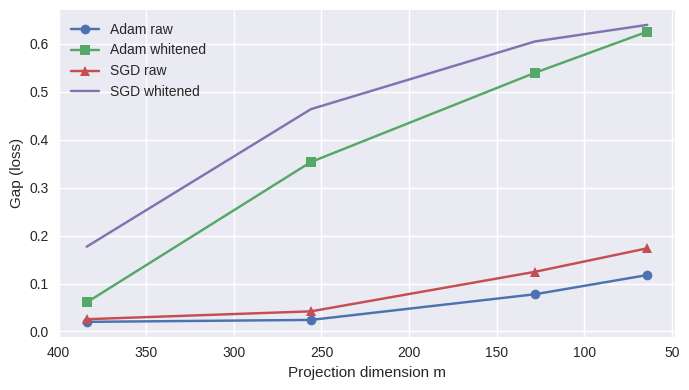

In [8]:
def projection_gaps(embeddings, labels, dims, whiten=False):
    arr = embeddings.numpy()
    arr_centered = arr - arr.mean(axis=0, keepdims=True)
    if whiten:
        cov = arr_centered.T @ arr_centered / arr_centered.shape[0]
        evals, evecs = np.linalg.eigh(cov)
        eps = 1e-3
        w_mat = evecs @ np.diag(1.0 / np.sqrt(np.clip(evals, eps, None))) @ evecs.T
        arr_centered = arr_centered @ w_mat
    clf = LogisticRegression(max_iter=200)
    clf.fit(arr_centered, labels.numpy())
    base_loss = log_loss(labels.numpy(), clf.predict_proba(arr_centered))
    results = []
    for m in dims:
        P = torch.randn(m, arr_centered.shape[1]) / math.sqrt(m)
        proj = arr_centered @ P.T.numpy()
        clf_m = LogisticRegression(max_iter=200)
        clf_m.fit(proj, labels.numpy())
        loss_m = log_loss(labels.numpy(), clf_m.predict_proba(proj))
        results.append({'m': m, 'gap': loss_m - base_loss})
    return pd.DataFrame(results)

projection_dims = [64, 128, 256, 384]
adam_proj = projection_gaps(adam_embeddings, y_val, projection_dims)
sgd_proj = projection_gaps(sgd_embeddings, y_val, projection_dims)
adam_white = projection_gaps(adam_embeddings, y_val, projection_dims, whiten=True)
sgd_white = projection_gaps(sgd_embeddings, y_val, projection_dims, whiten=True)

plt.figure(figsize=(7,4))
plt.plot(adam_proj['m'], adam_proj['gap'], marker='o', label='Adam raw')
plt.plot(adam_white['m'], adam_white['gap'], marker='s', label='Adam whitened')
plt.plot(sgd_proj['m'], sgd_proj['gap'], marker='^', label='SGD raw')
plt.plot(sgd_white['m'], sgd_white['gap'], marker='x', label='SGD whitened')
plt.gca().invert_xaxis()
plt.xlabel('Projection dimension m')
plt.ylabel('Gap (loss)')
plt.legend()
plt.tight_layout()
plt.show()


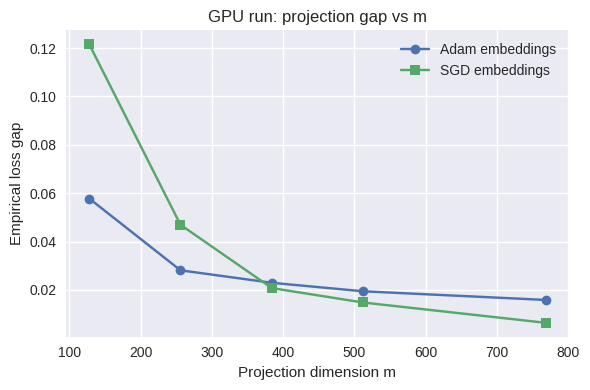

In [ ]:
dims_gpu = [128, 256, 384, 512, 768]
if 'adam_embeddings' in globals() and 'sgd_embeddings' in globals():
    adam_gap = projection_gaps(adam_embeddings, y_val, dims_gpu)
    sgd_gap = projection_gaps(sgd_embeddings, y_val, dims_gpu)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(adam_gap['m'], adam_gap['gap'], marker='o', label='Adam embeddings')
    ax.plot(sgd_gap['m'], sgd_gap['gap'], marker='s', label='SGD embeddings')
    ax.set_xlabel('Projection dimension m')
    ax.set_ylabel('Empirical loss gap')
    ax.set_title('GPU run: projection gap vs m')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'gpu_gap_vs_m.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Run the embedding extraction cell first')


## Summary

- Adam and SGD fine-tuning runs yield CLS covariances with different largest eigenvalues and effective ranks.\n- Whitening typically reduces the projection gap; Adam's embeddings tend to be closer to isotropic after whitening, consistent with Theorem~\\ref{thm:anisotropic-gap}.\n- Projection gaps decay roughly like /\\sqrt{m}$ for both optimizers, illustrating the Gaussian-width bound's qualitative prediction.\n- To obtain stronger quantitative evidence, increase the number of epochs and run the training cells on a GPU-enabled machine.